# Oglądam rozkłady chromVAR scrorów w grupach 1-1 i other (21.02.26)
Idea jest taka, żeby włączyć do klasyfikatora więcej informacji z rozkładów niż tylko różnica pomiędzy średnimi.

## W tym pliku będzie rysowanie wykresu zależności Wassersteina od różnicy średnich




In [1]:
from scipy.stats import wasserstein_distance
import os
import pandas as pd
import numpy as np
from collections import defaultdict
from collections.abc import Callable
import tqdm
import datetime
from scipy.stats import wasserstein_distance
from concurrent.futures import ProcessPoolExecutor, as_completed


In [2]:
###     MOTIF ENRICHEMENT DATA PREPARATION
def load_window(window: str):
    """ 
    Load and clean data (drop missing values while preserving loop and motif labels).

    Args:
        window (str): timepoint to process (eg. 'hrs06-08')

    Returns:
        Two cleaned DataFrames: loops_df, motifs_df (with labels as index/columns)
    """
    loops_path = f"data/new_time/hrs{window}_NNv1_time_matrix_loops.tsv"
    motifs_path = f"data/new_time/hrs{window}_NNv1_time_matrix_motifs.tsv"

    print(f"{datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\t\t Loading data...\n")
    loops_df = pd.read_csv(loops_path, sep='\t', index_col=0)  # First column is loop ID
    motifs_df = pd.read_csv(motifs_path, sep='\t', index_col=0)  # First column is motif ID

    print(f"{datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\t\t Converting DataFrames to numeric and dropping NaN values...\n")
    loops_df = loops_df.apply(pd.to_numeric, errors='coerce')
    loops_df.dropna(axis=1, inplace=True)  
    motifs_df = motifs_df.apply(pd.to_numeric, errors='coerce')
    motifs_df.dropna(axis=1, inplace=True) 
    
    # Keep only common cells (columns)
    common = list(set(loops_df.columns) & set(motifs_df.columns))
    loops_df = loops_df[common]
    motifs_df = motifs_df[common]
    
    return loops_df, motifs_df

def difference_of_means(loop_id: str, loops_df: pd.DataFrame, motifs_df: pd.DataFrame) -> tuple[str, dict]:
    # niech to po prostu zwraca różnicę
    """
    MOTIF ENRICHEMENT DATA PREPARATION
    The basic loop_processing_function.
    Averages chromVAR scores in groups 1-1 and other for all motifs for a given loop and returns the difference.
    
    Args:
        loop_id (str): Loop indentifier (like 'L417')
        loops_df, motifs_df (pd.DataFrame): dataframes loaded by load_winodow()

    Returns:
        loop_id (str): Loop indentifier (like 'L417')   # this is good for parallel execution???
        result (dict): a dictionary with motif names as keys and the difference between mean z-scores in cell populations as values.
    """
    result = {}  # Change to dict to store motif_id as key

    loop_values = loops_df.loc[loop_id]
    cells_11 = loop_values[loop_values == 11].index
    cells_other = loop_values.index.difference(cells_11)

    for motif_id in motifs_df.index:
        motif_values = motifs_df.loc[motif_id]
        mean_11 = np.mean(motif_values.loc[cells_11]) if len(cells_11) > 0 else np.nan
        mean_other = np.mean(motif_values.loc[cells_other]) if len(cells_other) > 0 else np.nan
        result[motif_id] = np.subtract(mean_11, mean_other)

    return loop_id, result

def loop_wasserstein(loop_id: str, loops_df: pd.DataFrame, motifs_df: pd.DataFrame) -> tuple[str, dict]:
    """
    Alternative loop_processing_function.
    Computes the wasserstein disctance chromVAR scores in groups 1-1 and other for all motifs for a given loop.
    
    Args:
        loop_id (str): Loop indentifier (like 'L417')
        loops_df, motifs_df (pd.DataFrame): dataframes loaded by load_window()

    Returns:
        loop_id (str): Loop indentifier (like 'L417')   # this is good for parallel execution???
        result (dict): a dictionary with motif names as keys and the Wasserstein distance between z-score distributions in cell populations as values.
    """
    result = {}  # Change to dict to store motif_id as key

    loop_values = loops_df.loc[loop_id]
    cells_11 = loop_values[loop_values == 11].index
    cells_other = loop_values.index.difference(cells_11)

    for motif_id in motifs_df.index:
        motif_values = motifs_df.loc[motif_id]
        # mean_11 = np.mean(motif_values.loc[cells_11]) if len(cells_11) > 0 else np.nan
        # mean_other = np.mean(motif_values.loc[cells_other]) if len(cells_other) > 0 else np.nan
        # result[motif_id] = np.subtract(mean_11, mean_other)
        one_one_values = motif_values.loc[cells_11] if len(cells_11) > 0 else np.nan
        other_values = motif_values.loc[cells_other] if len(cells_other) > 0 else np.nan
        result[motif_id] = wasserstein_distance(one_one_values, other_values)

    return loop_id, result

def motif_enrichement_parallel(window: str, loop_processing_function: Callable = difference_of_means, n_workers=6)-> pd.DataFrame: 
    """
    Parallel computation of motif enrichement data

    Args:
        window (str): timepoint to process (eg. 'hrs06-08')
        loop_processing_function (Callable): a function computing some kind of distance between motif score distribution in "1-1" and "other".

    Returns:
        motif_enrichments (pd.DataFrame):  a DataFrame with loops (rows), motifs (columns) and "1-1" - "other" difference (values).
    """

    loops_df, motifs_df = load_window(window)
    
    # data_3D = defaultdict(lambda: defaultdict(dict)) # previous implemenation
    all_data = defaultdict(dict)

    # Submit tasks
    with ProcessPoolExecutor(max_workers=n_workers) as executor:
        futures = {executor.submit(loop_processing_function, loop_id, loops_df, motifs_df): loop_id for loop_id in loops_df.index}

        for fut in tqdm.tqdm(as_completed(futures), total=len(futures)):
            loop_id, result = fut.result()
            all_data[loop_id] = result

    motif_enrichments = pd.DataFrame.from_dict(all_data, orient='index')
    return motif_enrichments


def process_loop(loop_id, loops_df, motifs_df):
    """
    OBSOLETE!
    The basic loop_processing_function.
    Averages chromVAR scores in groups 1-1 and other for all motifs for a given loop.
    
    Args:
        loop_id (str): Loop indentifier (like 'L417')
        loops_df, motifs_df (pd.DataFrame): dataframes loaded by load_winodow()

    Returns:
        loop_id (str): Loop indentifier (like 'L417')   # this is good for parallel execution???
        result (dict): a two-level dictionary where
            keys are motif names
            values are dictionaries of average score in populations '1-1' and 'other'
    """
    result = {}  # Change to dict to store motif_id as key

    loop_values = loops_df.loc[loop_id]
    cells_11 = loop_values[loop_values == 11].index
    cells_other = loop_values.index.difference(cells_11)

    for motif_id in motifs_df.index:
        motif_values = motifs_df.loc[motif_id]
        mean_11 = motif_values.loc[cells_11].mean() if len(cells_11) > 0 else np.nan
        mean_other = motif_values.loc[cells_other].mean() if len(cells_other) > 0 else np.nan
        result[motif_id] = {"1-1": mean_11, "other": mean_other}

    return loop_id, result


def process_window_parallel(window: str, loop_processing_function=process_loop, n_workers=6)-> defaultdict: 
    # AJk 21.02.26: Czy ten defaultdict jest tutaj potrzebny?
    """
    OBSOLETE!
    Parallel computation of data_3D using multiple processes.    

    Args:
        window (str): timepoint to process (eg. 'hrs06-08')

    Returns:
        data_3D (defaultdict): A three-level dictionary
    """
    
    loops_df, motifs_df = load_window(window)
    
    data_3D = defaultdict(lambda: defaultdict(dict))
    # print(f"{datetime.datetime.now():%Y-%m-%d %H:%M:%S}\t\tReal business begins\n")

    # Submit tasks
    with ProcessPoolExecutor(max_workers=n_workers) as executor:
        futures = {executor.submit(loop_processing_function, loop_id, loops_df, motifs_df): loop_id for loop_id in loops_df.index}

        for fut in tqdm.tqdm(as_completed(futures), total=len(futures)):
            loop_id, result = fut.result()
            data_3D[loop_id] = result

    return data_3D

def convert_2D(data_3D: dict)-> pd.DataFrame:
    """ OBSOLETE!
    For each (loop, motif) pair: compute the difference in mean chromVAR scores between populations of cells '1-1' and 'other'. 

    Args:  
        data_3D (dict): output of process_window_parallel()

    Returns:
        data_diff: a DataFrame with loops (rows), motifs (columns) and "1-1" - "other" difference (values).
        (data_diff is later reffered to as "motif enrichement matrix")
    """
    data_2D = {}
    for loop_id, motif_dict in data_3D.items():
        data_2D[loop_id] = {}
        for motif_id, profile_dict in motif_dict.items():
            mean_11 = profile_dict["1-1"]
            mean_other = profile_dict["other"]
            data_2D[loop_id][motif_id] = np.subtract(mean_11, mean_other)

    data_diff = pd.DataFrame.from_dict(data_2D, orient='index')
    return data_diff

## Wezmę te same trzy pętle w trzech oknach czasowych (będą 4 rozkłady na jednym obrazku)

In [26]:
windows = ['06-08', '10-12', '14-16']
loop_ids = ['L222', 'L400']
motif_ids = ['M0596-1.02', 'M6277-1.02']

In [ ]:
def distributions(loop_ids: list[str], motif_ids: list[str], loops_df: pd.DataFrame, motifs_df: pd.DataFrame) -> dict[dict]:
    """
    Args:
        loop_ids (list[str]): Loop indentifiers (like 'L417')
        motif_ids (list[str]): motif indentifiers (like 'M0111-1.02')
        loops_df, motifs_df (pd.DataFrame): dataframes loaded by load_window()

    Returns:
        result (dict): a dictionary with 
    """
    result = {loop: {motif: {"1-1": [], "1-0": [], "0-1": [], "0-0": []} for motif in motif_ids} for loop in loop_ids}
    for loop_id in loop_ids:
        loop_values = loops_df.loc[loop_id]
        cells_11 = loop_values[loop_values == 11].index
        cells_10 = loop_values[loop_values == 10].index
        cells_01 = loop_values[loop_values == 1].index
        cells_00 = loop_values[loop_values == 0].index

        for motif_id in motif_ids:
            motif_values = motifs_df.loc[motif_id]

            result[loop_id][motif_id]["1-1"] = motif_values.loc[cells_11] if len(cells_11) > 0 else np.nan
            result[loop_id][motif_id]["1-0"] = motif_values.loc[cells_10] if len(cells_10) > 0 else np.nan
            result[loop_id][motif_id]["0-1"] = motif_values.loc[cells_01] if len(cells_01) > 0 else np.nan
            result[loop_id][motif_id]["0-0"] = motif_values.loc[cells_00] if len(cells_00) > 0 else np.nan
            
    return result


In [30]:
big_dict = {w: {} for w in windows}

for window in windows[::-1]:
    
    big_dict[window] = distributions(loop_ids, motif_ids, *load_window(window=window))

2026-02-22 23:52:28		 Loading data...

2026-02-22 23:53:51		 Converting DataFrames to numeric and dropping NaN values...

2026-02-22 23:54:13		 Loading data...

2026-02-22 23:55:41		 Converting DataFrames to numeric and dropping NaN values...

2026-02-22 23:56:03		 Loading data...

2026-02-23 00:00:25		 Converting DataFrames to numeric and dropping NaN values...



In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def plot_distributions(window, loop_id, motif_id, big_dict: dict, save=False) -> None:
    """
    Plots four distributions ('1-1', '1-0', '0-1', '0-0')
    from the lowest-level dictionary produced by `distributions()`.

    Args:
        lowest_dict (dict): {
            "1-1": pd.Series | np.nan,
            "1-0": pd.Series | np.nan,
            "0-1": pd.Series | np.nan,
            "0-0": pd.Series | np.nan
        }
        title (str, optional): Plot title.
    """
    lowest_dict = big_dict[window][loop_id][motif_id]

    plt.figure(figsize=(8, 6))

    colors = {
        "1-1": "#1f77b4",
        "1-0": "#ff7f0e",
        "0-1": "#2ca02c",
        "0-0": "#d62728",
    }

    for label, values in lowest_dict.items():
        if isinstance(values, pd.Series) and len(values) > 0:
            sns.kdeplot(
                values,
                label=f"{label} (n={len(values)})",
                fill=True,
                alpha=0.35,     # transparency helps overlap visibility
                linewidth=2,
                color=colors[label]
            )
    plt.xlim(-3.5, 3.5)
    plt.legend()
    plt.xlabel("Value")
    plt.ylabel("Density")
    
    plt.title(f"ChromVAR scores distributions for {loop_id}, {motif_id} in window hrs{window}")
    
    plt.tight_layout()
    if save:
        dir = "results/figures/chromvar_distributions"
        os.makedirs(dir, exist_ok=True)
        path = os.path.join(dir, f"{loop_id}_{motif_id}_{window}.png")
        plt.savefig(path)
    else:
        plt.show()

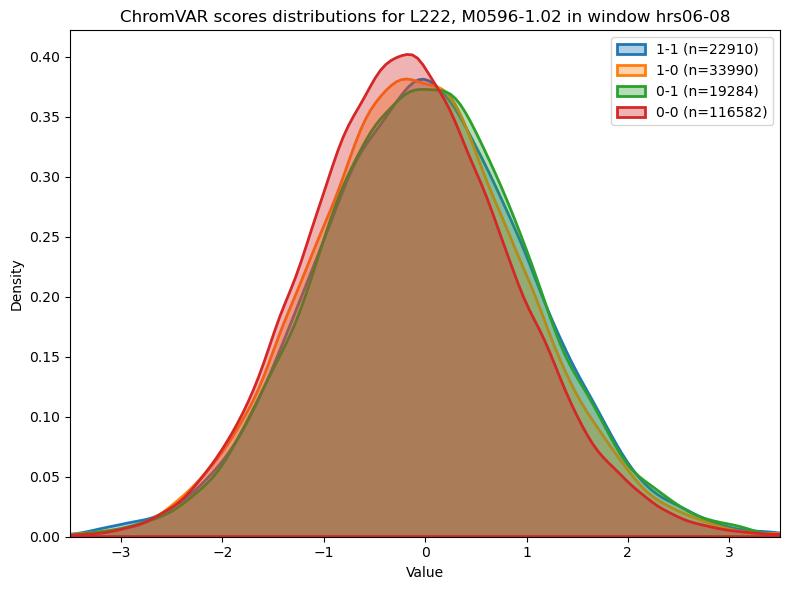

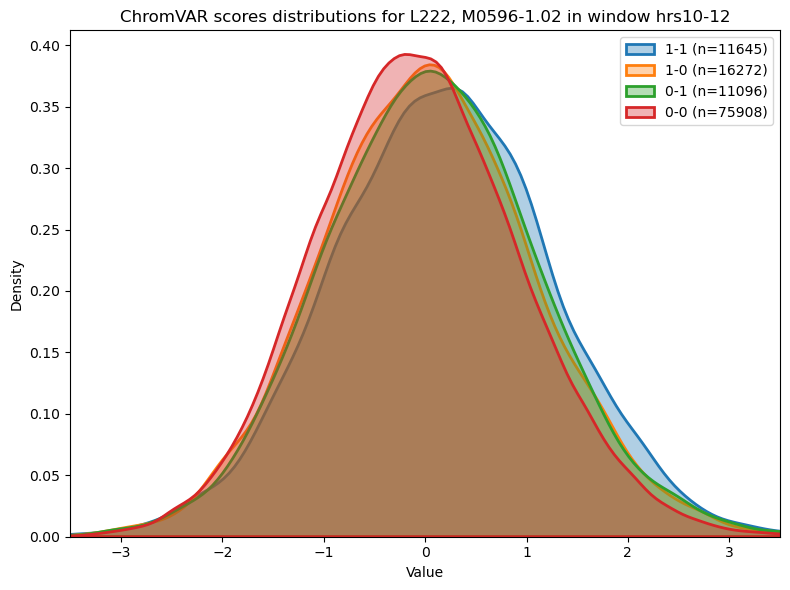

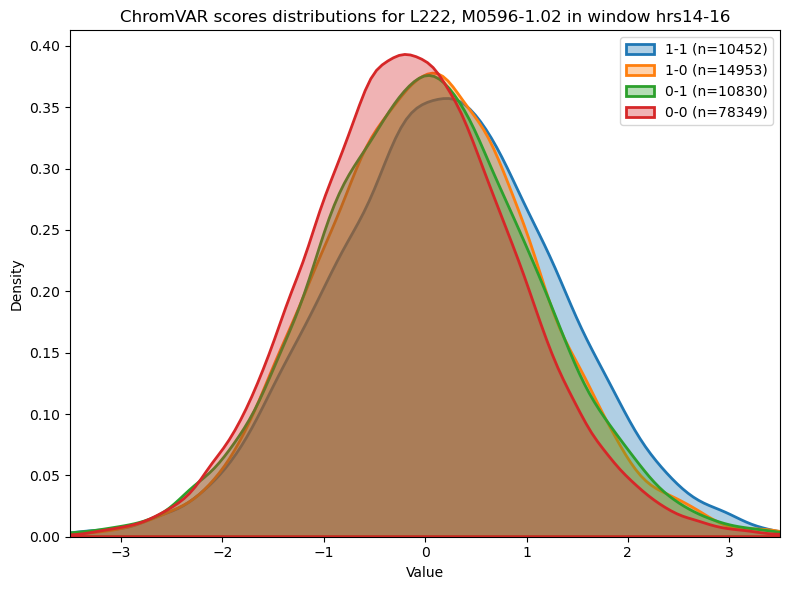

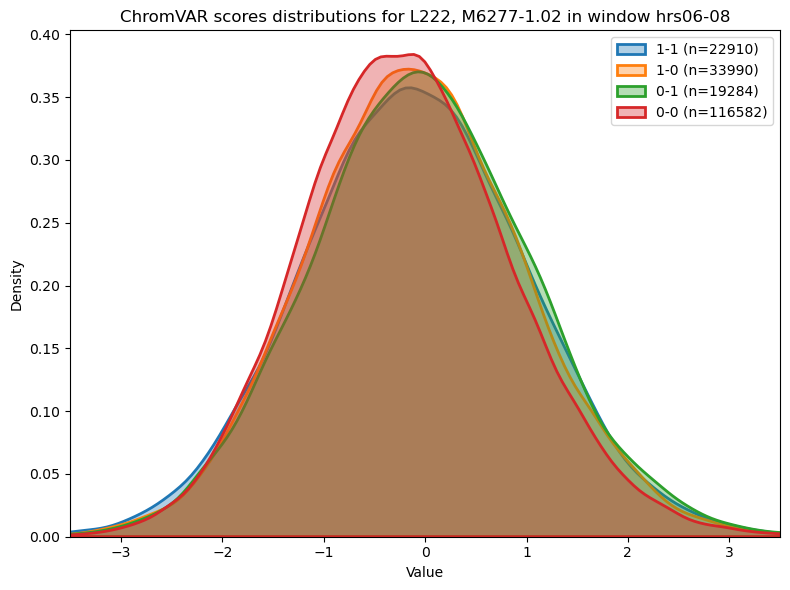

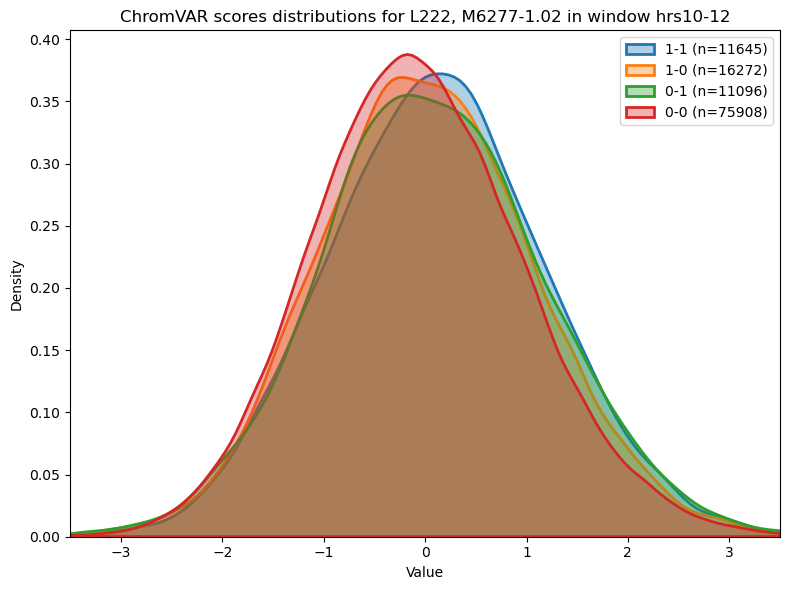

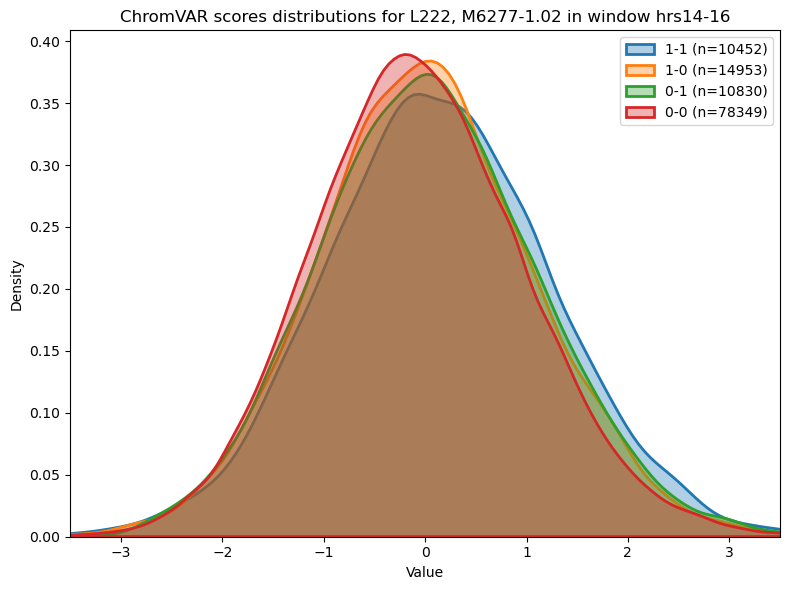

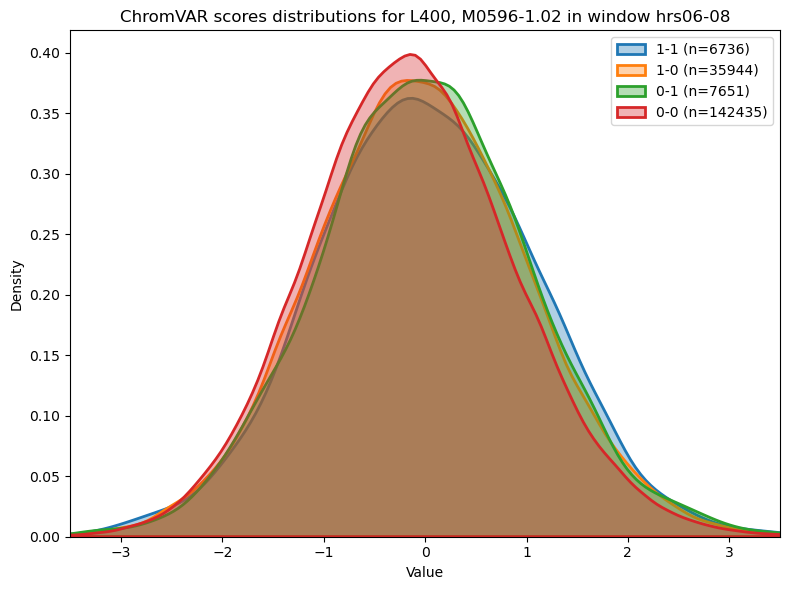

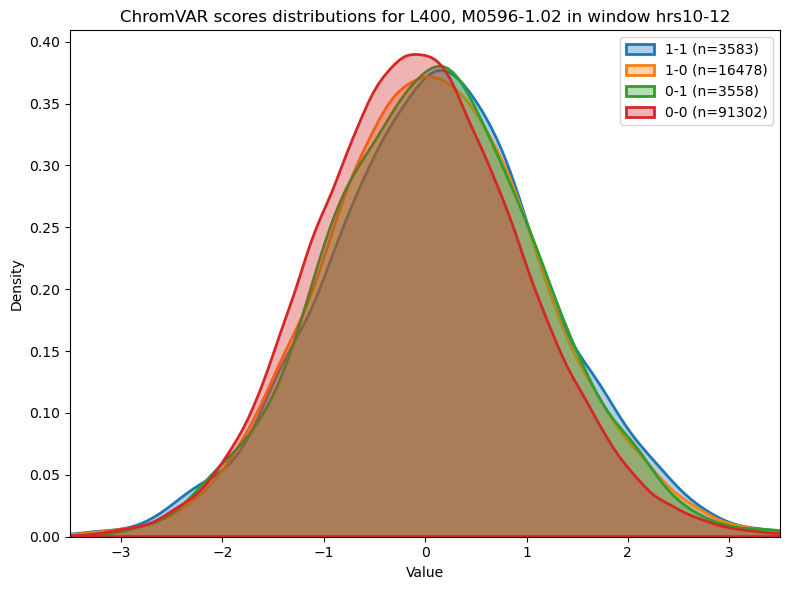

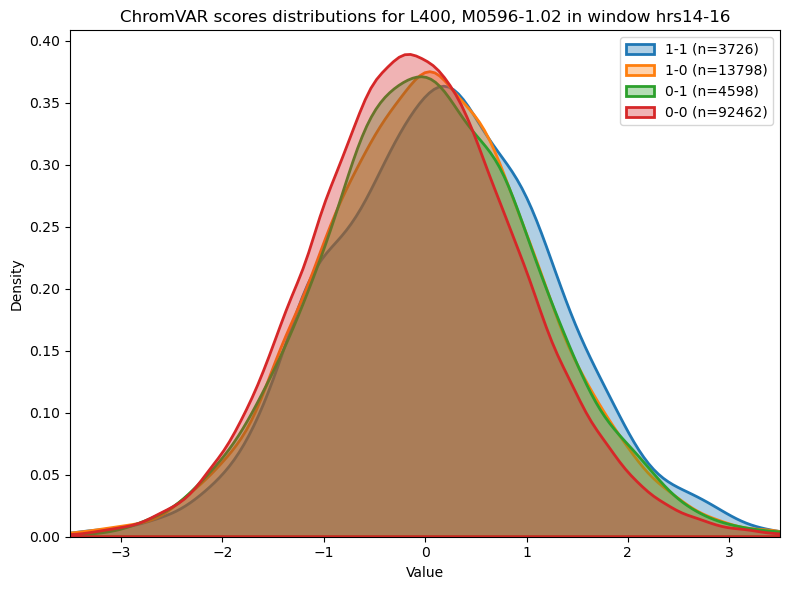

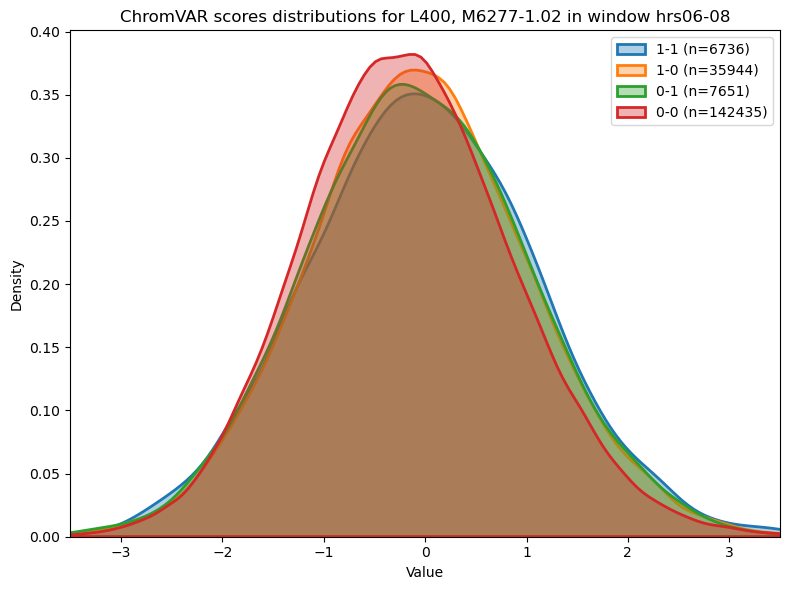

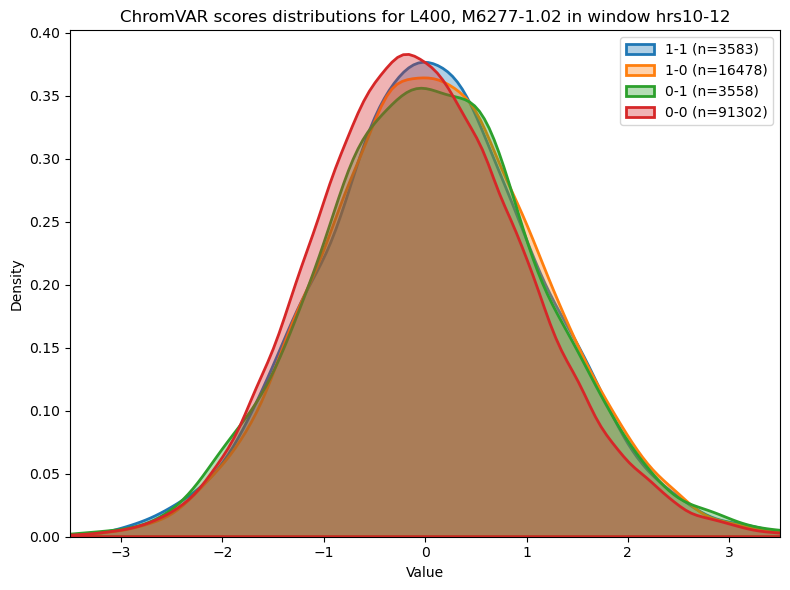

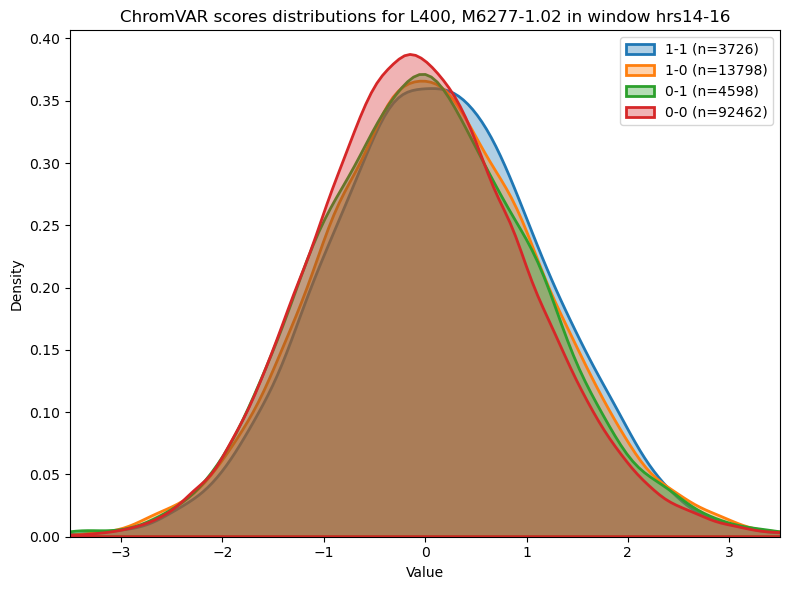

In [37]:
for loop_id in loop_ids:
    for motif_id in motif_ids:
        for window in windows:
            plot_distributions(window, loop_id, motif_id, big_dict, save=True)